# Cube-Single Subgoal Visualisation

Visualises predicted subgoals for **OTA** and **HIQL-Dual-DAF** on `cube-single`.
The high-level actor's latent prediction is decoded to world (X, Y) via a Ridge regression
linear probe, then projected to pixel coords and overlaid on rendered frames.


In [1]:
import os, sys, base64
os.environ['MUJOCO_GL'] = 'egl'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import HTML, display
from PIL import Image, ImageDraw
import imageio.v2 as imageio
from sklearn.linear_model import Ridge
import jax, jax.numpy as jnp, mujoco
import gymnasium as gym, ogbench, ogbench.manipspace
from utils.flax_utils import restore_agent
from utils.env_utils import make_env_and_datasets
from agents.ota.original import OTAAgent, get_config as get_config_ota
from agents.pi_hiql.hiql_dual_daf import HIQLDualDAFAgent, get_config as get_config_hiql
from agents.pi_hiql.hiql import HIQLAgent, get_config as get_config_hiql_orig

DATA_DIR  = 'toy_data/cube_single'
CKPT_OTA  = '/home/m_bobrin/dual-goal-representations/results/ota/cube-single-play-v0_ota_sd000/checkpoints'
CKPT_HIQL = '/home/m_bobrin/dual-goal-representations/results/hiql_dual_daf/cube-single-noisy/checkpoints'
CKPT_HIQL_ORIG = '/home/m_bobrin/dual-goal-representations/results/hiql/cube-single-noisy/checkpoints'
ENV_BY_AGENT = {
    'ota': 'cube-single-play-v0',
    'hiql': 'cube-single-noisy-v0',
    'hiql_orig': 'cube-single-noisy-v0',
}

XYZ_C = np.array([0.425, 0.0, 0.0]); XYZ_S = 10.0; GS = 3.0; CUB = 0.04
X_RNG = (0.30, 0.55); Y_RNG = (-0.30, 0.30)
TASKS = {
    1: dict(name='horizontal', init_xyz=np.array([0.425, 0.1,0.02]), goal_xyz=np.array([0.425,-0.1,0.02])),
    2: dict(name='vertical1',  init_xyz=np.array([0.350, 0.0,0.02]), goal_xyz=np.array([0.500, 0.0,0.02])),
    3: dict(name='vertical2',  init_xyz=np.array([0.500, 0.0,0.02]), goal_xyz=np.array([0.350, 0.0,0.02])),
    4: dict(name='diagonal1',  init_xyz=np.array([0.350,-0.2,0.02]), goal_xyz=np.array([0.500, 0.2,0.02])),
    5: dict(name='diagonal2',  init_xyz=np.array([0.350, 0.2,0.02]), goal_xyz=np.array([0.500,-0.2,0.02])),
}

def eff(obs):  return obs[...,12:15]/XYZ_S + XYZ_C
def blk(obs, k=0): s=19+k*9; return obs[...,s:s+3]/XYZ_S + XYZ_C

def load_traj(data_dir, task_id):
    d = dict(np.load(f'{data_dir}/task{task_id}.npz', allow_pickle=True))
    obs = d.get('observations', next(iter(d.values())))
    print(f'  task{task_id}.npz: {len(obs)} steps'); return d

def first_episode(d):
    obs = d.get('observations', next(iter(d.values()))).astype(np.float32)
    if 'terminals' in d: obs = obs[:int(np.argmax(d['terminals'].astype(bool)))+1]
    return obs

def _set_render_size(env, sz):
    raw = env.unwrapped
    if hasattr(raw, '_model') and hasattr(raw._model.vis, 'global_'):
        raw._model.vis.global_.offwidth = max(int(raw._model.vis.global_.offwidth), int(sz))
        raw._model.vis.global_.offheight = max(int(raw._model.vis.global_.offheight), int(sz))
    if hasattr(raw, '_render_width'):
        raw._render_width = int(sz)
    if hasattr(raw, '_render_height'):
        raw._render_height = int(sz)
    renderer = getattr(raw, '_renderer', None)
    if renderer is not None:
        renderer.close()
    if hasattr(raw, '_renderer'):
        raw._renderer = None

def make_env(task_id, sz=200, env_name='cube-single-play-v0', frame_stack=None):
    # Match eval_pretrained.py: build the OGBench task env from the evaluated env_name.
    env, _, _ = make_env_and_datasets(env_name, frame_stack=frame_stack)
    _set_render_size(env, sz)
    env.reset(options={'task_id': task_id}); return env

def set_state(env, obs):
    r = env.unwrapped
    r._data.qpos[r._arm_joint_ids] = obs[0:6]
    r._data.qvel[r._arm_joint_ids] = obs[6:12]
    r._data.qpos[r._gripper_opening_joint_id] = float(np.clip(obs[17]/GS,0,1))*0.8
    r._data.joint('object_joint_0').qpos[:3] = obs[19:22]/XYZ_S + XYZ_C
    r._data.joint('object_joint_0').qpos[3:]  = obs[22:26]
    mujoco.mj_forward(r._model, r._data)

def resize(env, sz):
    _set_render_size(env, sz)

def get_cam(env, name='front_pixels'):
    m = env.unwrapped._model
    cid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, name)
    if cid < 0: cid, name = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, 'front'), 'front'
    return cid, name

def w2px(model, data, cid, pt, W, H):
    cp = data.cam_xpos[cid].copy(); cm = data.cam_xmat[cid].copy().reshape(3,3)
    c = cm.T @ (np.asarray(pt,float)-cp); d = -c[2]
    if d < 1e-4: return None
    f = (H/2)/np.tan(np.radians(model.cam_fovy[cid])/2)
    return np.array([W/2+f*c[0]/d, H/2-f*c[1]/d])

def precalc_px(env, obs_seq, cam='front_pixels'):
    r = env.unwrapped; m=r._model; da=r._data; W=r._render_width; H=r._render_height
    cid,cam = get_cam(env,cam); set_state(env,obs_seq[0])
    return cid,cam,[w2px(m,da,cid,p,W,H) for p in eff(obs_seq)],[w2px(m,da,cid,p,W,H) for p in blk(obs_seq)]

def pickup_idx(obs_seq, thr=0.032, mi=5):
    z = blk(obs_seq)[:,2]; c = np.where(z>thr)[0]; c=c[c>mi]
    return int(c[0]) if len(c) else len(obs_seq)-1

def pregrasp(obs_seq, pi, n=8):
    return list(range(max(0, pi-n), pi))

def reticle(draw, cx, cy, r=5, col=(255,215,0)):
    ring = r+5
    draw.ellipse([cx-ring,cy-ring,cx+ring,cy+ring], outline=(*col,180), width=1)
    draw.ellipse([cx-r,cy-r,cx+r,cy+r], fill=(*col,220))
    for dx,dy in [(-1,0),(1,0),(0,-1),(0,1)]:
        draw.line([(cx+dx*(ring+2),cy+dy*(ring+2)),(cx+dx*(ring+7),cy+dy*(ring+7))], fill=(*col,200), width=2)

print('Setup complete.')

Setup complete.


## Subgoal Prediction Core

| Agent | Representation space | Probe fitted |
|-------|----------------------|--------------|
| OTA | `goal_rep([obs; g])` — obs-dependent | per query frame |
| HIQL | `psi(g) = rep_value(g)` — goal-only | **once** per trajectory |


In [2]:
@jax.jit
def _ota_rep(network, obs, goal):
    r = network.select('high_actor')(obs, goal).mode()
    return r / jnp.linalg.norm(r, axis=-1, keepdims=True) * jnp.sqrt(r.shape[-1])

@jax.jit
def _ota_greps(network, cat): return network.select('goal_rep')(cat)

@jax.jit
def _hiql_rep(network, obs, goal):
    r = network.select('high_actor')(obs, goal).mode()
    n = jnp.linalg.norm(r, axis=-1, keepdims=True) + 1e-8
    return r / n * jnp.sqrt(r.shape[-1])

@jax.jit
def _hiql_psi(network, goals):
    p = network.select('rep_value')(goals)
    n = jnp.linalg.norm(p, axis=-1, keepdims=True) + 1e-8
    return p / n * jnp.sqrt(p.shape[-1])

def fit_ota_probe(agent, ref_obs, traj_obs):
    M = len(traj_obs)
    cat = jnp.concatenate([jnp.tile(jnp.array(ref_obs)[None],(M,1)), jnp.array(traj_obs)],axis=-1)
    reps = np.array(_ota_greps(agent.network, cat))
    return Ridge(alpha=0.1).fit(reps, blk(traj_obs)[:,:2])

def fit_hiql_probe(agent, traj_obs):
    psi = np.array(_hiql_psi(agent.network, jnp.array(traj_obs)))
    return Ridge(alpha=0.1).fit(psi, blk(traj_obs)[:,:2])

def fit_hiql_orig_probe(agent, ref_obs, traj_obs):
    # phi([s; g]) is obs-dependent (same interface as OTA goal_rep) — refit per query.
    return fit_ota_probe(agent, ref_obs, traj_obs)

def predict_sg_xyz(agent, atype, obs, goal_obs, traj_obs, hiql_probe=None):
    """
    Decode high-level actor subgoal -> block world (X, Y, Z=0.02).
    OTA:       probe refitted per call (goal_rep phi([s;g]) is obs-dependent).
    HIQL:      pass pre-fitted hiql_probe; auto-fitted if None (psi(g) is goal-only).
    hiql_orig: probe refitted per call (phi([s;g]) obs-dependent, rep_dim=10).
    """
    oj, gj = jnp.array(obs[None]), jnp.array(goal_obs[None])
    if atype == 'ota':
        probe  = fit_ota_probe(agent, obs, traj_obs)
        sg_rep = np.array(_ota_rep(agent.network, oj, gj))[0]
    elif atype == 'hiql':
        probe  = hiql_probe if hiql_probe is not None else fit_hiql_probe(agent, traj_obs)
        sg_rep = np.array(_hiql_rep(agent.network, oj, gj))[0]
    elif atype == 'hiql_orig':
        probe  = fit_hiql_orig_probe(agent, obs, traj_obs)
        sg_rep = np.array(_hiql_rep(agent.network, oj, gj))[0]
    else:
        raise ValueError(f'Unknown agent_type {atype!r}')
    xy = probe.predict(sg_rep[None])[0]
    return np.array([xy[0], xy[1], 0.02])

print('Subgoal prediction ready.')

Subgoal prediction ready.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Load agents from checkpoints
# ═══════════════════════════════════════════════════════════════════════════════
TASK_ID  = 1
d        = load_traj(DATA_DIR, TASK_ID)
obs_seq  = first_episode(d)
goal_obs = obs_seq[-1]           # task-completion state as goal
ex_obs   = obs_seq[:1]
ex_act   = d.get('actions', np.zeros((1,5), np.float32))[:1]

# ── OTA ───────────────────────────────────────────────────────────────────────
cfg_ota = get_config_ota()
cfg_ota.rep_dim = 256           # adjust to match your checkpoint
ota = OTAAgent.create(0, ex_obs, ex_act, cfg_ota)
ota = restore_agent(ota, CKPT_OTA, step=500_000)
print('OTA loaded.')

# ── HIQL-Dual-DAF ─────────────────────────────────────────────────────────────
cfg_hiql = get_config_hiql()    # goalrep_dim=256 by default
hiql = HIQLDualDAFAgent.create(0, ex_obs, ex_act, cfg_hiql)
hiql = restore_agent(hiql, CKPT_HIQL, step=1_000_000)
print('HIQL loaded.')

# ── Original HIQL ─────────────────────────────────────────────────────────────
cfg_hiql_orig = get_config_hiql_orig()   # rep_dim=10 by default; adjust if checkpoint differs
hiql_orig = HIQLAgent.create(0, ex_obs, ex_act, cfg_hiql_orig)
hiql_orig = restore_agent(hiql_orig, CKPT_HIQL_ORIG, step=200_000)
print('HIQL-orig loaded.')

  task1.npz: 64 steps
Restored agent from step 500000 in /home/m_bobrin/dual-goal-representations/results/ota/cube-single-play-v0_ota_sd000/checkpoints
OTA loaded.
Restored agent from step 1000000 in /home/m_bobrin/dual-goal-representations/results/hiql_dual_daf/cube-single-noisy/checkpoints
HIQL loaded.
Restored agent from step 200000 in /home/m_bobrin/dual-goal-representations/results/hiql/cube-single-noisy/checkpoints
HIQL-orig loaded.


## Expert Trajectory — Subgoal Visualisation

Paper-quality figure: rendered pre-pickup frames with gold reticle = predicted subgoal,
and a 2-D bird's-eye view with arrows showing the agent's misaligned block target.


  task1.npz: 64 steps


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[comparison] pickup t=31; visualizing latest pre-grasp state t=30
  Saved -> expert_subgoals_comparison.pdf


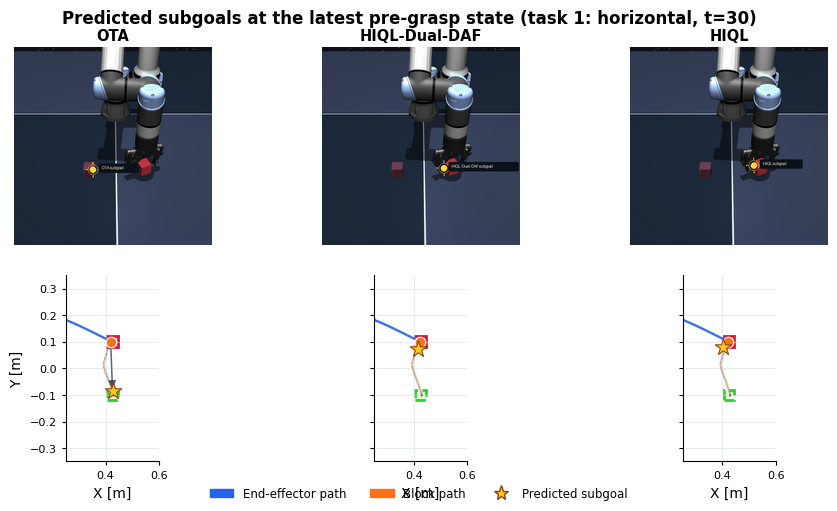

/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[ota video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> ota_expert_subgoals.gif
  Done.



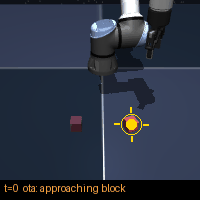

[hiql video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  Saved -> hiql_expert_subgoals.gif
  Done.



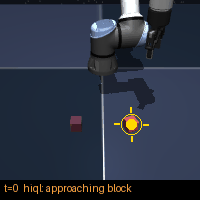

[hiql_orig video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  50/60
  60/60
  Rendering ...
  Saved -> hiql_orig_expert_subgoals.gif
  Done.



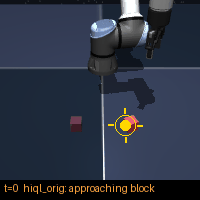

In [9]:
def _draw_2d_bg(obs_seq, task_id, ax):
    ep, bp = eff(obs_seq), blk(obs_seq); N = len(obs_seq)
    for i in range(N-1):
        t=i/max(N-2,1)
        ax.plot(ep[i:i+2,0],ep[i:i+2,1],color=(t,0,1-t,0.22),lw=1.2)
        ax.plot(bp[i:i+2,0],bp[i:i+2,1],color=(0.9-0.85*t,0.1+0.85*t,0,0.18),lw=1.8,ls='--')
    task=TASKS[task_id]; h=CUB/2
    ix,iy=task['init_xyz'][:2]; gx,gy=task['goal_xyz'][:2]
    ax.add_patch(mpatches.Rectangle((ix-h,iy-h),CUB,CUB,lw=2,edgecolor='crimson',facecolor=(1,.3,.3,.18),label='Block init'))
    ax.add_patch(mpatches.Rectangle((gx-h,gy-h),CUB,CUB,lw=2,edgecolor='limegreen',ls='--',facecolor=(.3,1,.3,.18),label='Goal'))
    ax.set_xlim(X_RNG[0]-.05,X_RNG[1]+.05); ax.set_ylim(Y_RNG[0]-.05,Y_RNG[1]+.05)
    ax.set_aspect('equal'); ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.grid(True,alpha=0.18)


def _agent_label(atype):
    return {'ota': 'OTA', 'hiql': 'HIQL-Dual-DAF', 'hiql_orig': 'HIQL'}[atype]

def _style_paper_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8, width=0.8, length=3)
    ax.grid(True, color='#d8dee8', lw=0.55, alpha=0.75)

def _draw_reticle_label(img, model, data, cid, xyz, label, W, H):
    draw = ImageDraw.Draw(img, 'RGBA')
    px = w2px(model, data, cid, xyz, W, H)
    if px is None:
        return img
    cx, cy = int(px[0]), int(px[1])
    reticle(draw, cx, cy, r=8, col=(255, 214, 64))
    text = f'{label} subgoal'
    box_w = 8 * len(text) + 16
    x0 = min(max(cx + 16, 4), W - box_w - 4)
    y0 = min(max(cy - 16, 4), H - 28)
    draw.rounded_rectangle([x0, y0, x0 + box_w, y0 + 24], radius=4, fill=(12, 18, 28, 190))
    draw.text((x0 + 8, y0 + 5), text, fill=(255, 244, 190, 255))
    return img

def _single_pregrasp_subgoal(agent, atype, obs_seq, goal_obs, ti):
    hp = fit_hiql_probe(agent, obs_seq) if atype == 'hiql' else None
    return predict_sg_xyz(agent, atype, obs_seq[ti], goal_obs, obs_seq, hp)

def visualize_expert_subgoals(agent, atype, obs_seq, goal_obs, task_id, env,
                               n=6, sz=480, cam='front_pixels', save=None, dpi=600):
    pi = pickup_idx(obs_seq)
    pre = pregrasp(obs_seq, pi, n=n)
    if len(pre) == 0:
        raise ValueError('No pre-grasp window. Lower lift_thresh or increase n.')
    ti = pre[-1]
    sg = _single_pregrasp_subgoal(agent, atype, obs_seq, goal_obs, ti)
    print(f'[{atype}] pickup t={pi}; visualizing latest pre-grasp state t={ti}')
    resize(env, sz)
    raw = env.unwrapped; model=raw._model; data=raw._data; W,H=sz,sz
    cid, cam = get_cam(env, cam)
    set_state(env, obs_seq[ti])
    img = Image.fromarray(raw.render(camera=cam)).convert('RGBA')
    img = _draw_reticle_label(img, model, data, cid, sg, _agent_label(atype), W, H)

    with plt.rc_context({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans'}):
        fig, (ax_img, ax_xy) = plt.subplots(1, 2, figsize=(7.2, 3.15), gridspec_kw={'width_ratios': [1.0, 1.05]}, facecolor='white')
        ax_img.imshow(np.array(img.convert('RGB')), interpolation='lanczos')
        ax_img.axis('off')
        ax_img.set_title(f'{_agent_label(atype)}: t={ti}', fontsize=10, fontweight='bold', pad=6)
        _draw_2d_bg(obs_seq, task_id, ax_xy)
        ep, bp = eff(obs_seq), blk(obs_seq)
        ax_xy.scatter(ep[ti,0], ep[ti,1], c='#2563eb', s=58, zorder=9, edgecolors='white', lw=0.8, label='End effector')
        ax_xy.scatter(bp[ti,0], bp[ti,1], c='#f97316', s=70, zorder=10, edgecolors='white', lw=0.8, label='Block')
        ax_xy.scatter(sg[0], sg[1], c='#facc15', s=160, zorder=11, marker='*', edgecolors='#92400e', lw=0.8, label='Predicted subgoal')
        ax_xy.annotate('', xy=(sg[0], sg[1]), xytext=(ep[ti,0], ep[ti,1]), arrowprops=dict(arrowstyle='-|>', color='#334155', lw=1.2, alpha=0.8, mutation_scale=12))
        ax_xy.set_title('XY projection', fontsize=10, fontweight='bold', pad=6)
        ax_xy.legend(loc='upper right', fontsize=7, frameon=True, framealpha=0.9, borderpad=0.4)
        fig.tight_layout(pad=0.7)
        if save:
            fig.savefig(save, dpi=dpi, bbox_inches='tight', facecolor='white')
            print(f'  Saved -> {save}')
    return fig

def visualize_expert_subgoals_comparison(agent_items, obs_seq, goal_obs, task_id, env,
                                         n=6, sz=520, cam='front_pixels', save='expert_subgoals_comparison.pdf', dpi=600):
    pi = pickup_idx(obs_seq)
    pre = pregrasp(obs_seq, pi, n=n)
    if len(pre) == 0:
        raise ValueError('No pre-grasp window. Lower lift_thresh or increase n.')
    ti = pre[-1]
    print(f'[comparison] pickup t={pi}; visualizing latest pre-grasp state t={ti}')
    resize(env, sz)
    raw = env.unwrapped; model=raw._model; data=raw._data; W,H=sz,sz
    cid, cam = get_cam(env, cam)
    ep, bp = eff(obs_seq), blk(obs_seq)
    rows = []
    for agent, atype in agent_items:
        sg = _single_pregrasp_subgoal(agent, atype, obs_seq, goal_obs, ti)
        set_state(env, obs_seq[ti])
        img = Image.fromarray(raw.render(camera=cam)).convert('RGBA')
        img = _draw_reticle_label(img, model, data, cid, sg, _agent_label(atype), W, H)
        rows.append((atype, sg, np.array(img.convert('RGB'))))

    with plt.rc_context({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.family': 'DejaVu Sans'}):
        fig = plt.figure(figsize=(3.15 * len(rows), 5.05), facecolor='white')
        gs = gridspec.GridSpec(2, len(rows), figure=fig, height_ratios=[1.06, 1.0], hspace=0.16, wspace=0.08, left=0.035, right=0.99, top=0.91, bottom=0.09)
        for col, (atype, sg, img) in enumerate(rows):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img, interpolation='lanczos')
            ax.axis('off')
            ax.set_title(_agent_label(atype), fontsize=10.5, fontweight='bold', pad=5)
            ax = fig.add_subplot(gs[1, col])
            _draw_2d_bg(obs_seq, task_id, ax)
            ax.plot(ep[:ti+1,0], ep[:ti+1,1], color='#2563eb', lw=1.7, alpha=0.85)
            ax.plot(bp[:ti+1,0], bp[:ti+1,1], color='#f97316', lw=1.9, alpha=0.85)
            ax.scatter(ep[ti,0], ep[ti,1], c='#2563eb', s=48, zorder=9, edgecolors='white', lw=0.8)
            ax.scatter(bp[ti,0], bp[ti,1], c='#f97316', s=58, zorder=10, edgecolors='white', lw=0.8)
            ax.scatter(sg[0], sg[1], c='#facc15', s=155, zorder=11, marker='*', edgecolors='#92400e', lw=0.8)
            ax.annotate('', xy=(sg[0], sg[1]), xytext=(ep[ti,0], ep[ti,1]), arrowprops=dict(arrowstyle='-|>', color='#334155', lw=1.1, alpha=0.8, mutation_scale=11))
            _style_paper_axes(ax)
            if col > 0:
                ax.set_ylabel('')
                ax.set_yticklabels([])
        task = TASKS[task_id]
        fig.suptitle(f'Predicted subgoals at the latest pre-grasp state (task {task_id}: {task["name"]}, t={ti})', fontsize=12, fontweight='bold', y=0.985)
        handles = [
            mpatches.Patch(color='#2563eb', label='End-effector path'),
            mpatches.Patch(color='#f97316', label='Block path'),
            plt.Line2D([0], [0], marker='*', color='w', label='Predicted subgoal', markerfacecolor='#facc15', markeredgecolor='#92400e', markersize=11),
        ]
        fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, fontsize=8.5)
        if save:
            fig.savefig(save, dpi=dpi, bbox_inches='tight', facecolor='white')
            print(f'  Saved -> {save}')
    return fig


def subgoal_video(agent, atype, obs_seq, goal_obs, task_id, env,
    sz=200, fps=8, max_frames=60, tstep=2, save_path=None):
    """
    Full-trajectory GIF: trajectory traces + gold reticle at predicted subgoal.
    save_path: if given (e.g. "ota_rollout.gif"), also writes the GIF to disk.
    """
    N_full   = len(obs_seq)
    imap     = np.linspace(0, N_full-1, min(max_frames, N_full), dtype=int)
    obs_vis  = obs_seq[imap]; N = len(obs_vis)
    pi       = pickup_idx(obs_seq)
    resize(env, sz)

    raw = env.unwrapped; model=raw._model; data=raw._data; W,H=sz,sz
    cid, cam, epx, bpx = precalc_px(env, obs_vis)

    # HIQL probe: fit once (psi is obs-independent); OTA: per frame
    hp = fit_hiql_probe(agent, obs_seq) if atype == 'hiql' else None
    print(f'[{atype} video] Computing {N} subgoals ...')
    sgpx = []
    for i, obs in enumerate(obs_vis):
        sg = predict_sg_xyz(agent, atype, obs, goal_obs, obs_seq, hp)
        sgpx.append(w2px(model, data, cid, sg, W, H))
        if (i+1) % 10 == 0: print(f'  {i+1}/{N}')

    print('  Rendering ...')
    frames, st = [], max(1, tstep)
    for i, obs in enumerate(obs_vis):
        set_state(env, obs)
        img  = Image.fromarray(raw.render(camera=cam)).convert('RGBA')
        draw = ImageDraw.Draw(img, 'RGBA')

        # Trajectory traces
        past = list(range(0, i+1, st))
        for k in range(len(past)-1):
            j0,j1 = past[k],past[k+1]; t=(j0+j1)/2/max(N-1,1)
            if epx[j0] is not None and epx[j1] is not None:
                draw.line([(int(epx[j0][0]),int(epx[j0][1])),(int(epx[j1][0]),int(epx[j1][1]))],
                          fill=(int(255*t),0,int(255*(1-t)),200),width=2)
            if bpx[j0] is not None and bpx[j1] is not None:
                draw.line([(int(bpx[j0][0]),int(bpx[j0][1])),(int(bpx[j1][0]),int(bpx[j1][1]))],
                          fill=(int(220*(1-t)),int(200*t),30,200),width=3)

        # Gold subgoal reticle
        if sgpx[i] is not None:
            reticle(draw, int(sgpx[i][0]), int(sgpx[i][1]), r=5, col=(255,215,0))

        # Phase banner
        ti    = int(imap[i])
        phase = 'approaching block' if ti < pi else 'grasping / placing'
        col   = (255,165,60,220) if ti < pi else (100,230,100,220)
        draw.rectangle([0,H-20,W,H],fill=(0,0,0,130))
        draw.text((4,H-18),f't={ti}  {atype}: {phase}',fill=col)
        frames.append(np.array(img.convert('RGB')))

    tmp = f'/tmp/{atype}_rollout_task{task_id}.gif'
    imageio.mimwrite(tmp, frames, format='GIF', fps=fps, loop=0)
    if save_path is not None:
        import shutil as _sh; _sh.copy(tmp, save_path)
        print(f'  Saved -> {save_path}')
    with open(tmp,'rb') as f: b64=base64.b64encode(f.read()).decode()
    print('  Done.')
    return HTML(f'<h3>{atype.upper()} rollout — Task {task_id}</h3>'
                f'<p style="font-size:12px"><b>Gold reticle</b> = predicted subgoal block XY | '
                f'blue-red = arm | orange-green = block</p>'
                f'<img src="data:image/gif;base64,{b64}" style="width:{sz*2}px; image-rendering:pixelated"/>')

# ── Run for both agents ───────────────────────────────────────────────────────
TASK_ID  = 1
d        = load_traj(DATA_DIR, TASK_ID)
obs_seq  = first_episode(d)
goal_obs = obs_seq[-1]
env      = make_env(TASK_ID, sz=520)

fig_subgoals = visualize_expert_subgoals_comparison(
    [(ota, 'ota'), (hiql, 'hiql'), (hiql_orig, 'hiql_orig')],
    obs_seq,
    goal_obs,
    TASK_ID,
    env,
    sz=520,
    save='expert_subgoals_comparison.pdf',
)
plt.show()

# ── Video: full expert trajectory with subgoal reticle updated every frame ────
# Uses the same subgoal_video() function as the rollout cell — just pass obs_seq.
# env.reset restores the goal mocap marker so it appears in the rendered frames.

env.reset(options={'task_id': TASK_ID})
display(subgoal_video(ota, 'ota', obs_seq, goal_obs, TASK_ID, env, sz=200, save_path='ota_expert_subgoals.gif'))

env.reset(options={'task_id': TASK_ID})
display(subgoal_video(hiql, 'hiql', obs_seq, goal_obs, TASK_ID, env, sz=200, save_path='hiql_expert_subgoals.gif'))

env.reset(options={'task_id': TASK_ID})
display(subgoal_video(hiql_orig, 'hiql_orig', obs_seq, goal_obs, TASK_ID, env, sz=200, save_path='hiql_orig_expert_subgoals.gif'))

## Own Rollout — Model-Driven Trajectory with Subgoal Video

Roll out each agent's own policy (no expert demos) and visualise the predicted subgoal
block position at every frame as an animated GIF.


/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Rolling out OTA on cube-single-play-v0, Task 2
  Steps: 201  |  Success: False
[ota video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> ota_rollout_task2.gif
  Done.



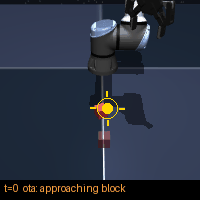

/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Rolling out HIQL on cube-single-noisy-v0, Task 2
  Steps: 201  |  Success: False
[hiql video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> hiql_rollout_task2.gif
  Done.



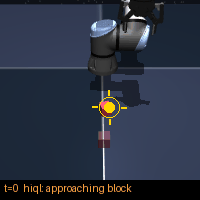

/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/m_bobrin/dual-goal-representations/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Rolling out HIQL_ORIG on cube-single-noisy-v0, Task 2
  Steps: 201  |  Success: False
[hiql_orig video] Computing 60 subgoals ...
  10/60
  20/60
  30/60
  40/60
  50/60
  60/60
  Rendering ...
  Saved -> hiql_orig_rollout_task2.gif
  Done.



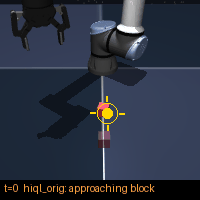

In [8]:
def rollout(agent, env, task_id, max_steps=None, seed=0, temp=0.0):
    """Roll out agent using the same env reset and action-call convention as eval_pretrained.py."""
    obs, info = env.reset(options={'task_id': task_id})
    raw    = env.unwrapped
    goal = info.get("goal") 
    if goal is None: raise RuntimeError('_cur_goal_ob is None — env must be in task mode.')
    seq, success, rng = [obs.copy()], False, jax.random.key(seed)
    steps = 0
    while True:
        rng, srng = jax.random.split(rng)
        action = np.array(agent.sample_actions(jnp.array(obs), jnp.array(goal), seed=srng, temperature=temp))
        action = np.clip(action, -1, 1)
        obs, _, term, trunc, info = env.step(action)
        seq.append(obs.copy())
        success = bool(info.get('success', False))
        steps += 1
        if term or trunc or (max_steps is not None and steps >= max_steps): break
    return np.array(seq, np.float32), np.array(goal, np.float32), success

# ── Roll out both agents ──────────────────────────────────────────────────────
TASK_ID = 2
for agent, atype in [(ota, 'ota'), (hiql, 'hiql'), (hiql_orig, 'hiql_orig')]:
    env_name = ENV_BY_AGENT[atype]
    env_r = make_env(TASK_ID, sz=200, env_name=env_name)
    print('='*60)
    print(f'Rolling out {atype.upper()} on {env_name}, Task {TASK_ID}')
    obs_r, goal_r, ok = rollout(agent, env_r, TASK_ID, seed=0)
    print(f'  Steps: {len(obs_r)}  |  Success: {ok}')
    env_r.reset(options={'task_id': TASK_ID})
    display(subgoal_video(agent, atype, obs_r, goal_r, TASK_ID, env_r,
                          save_path=f'{atype}_rollout_task{TASK_ID}.gif'))